# Part 5: Multifactor Models and Cross-Sectional Return Prediction

*"A single factor is a story. A multifactor model is a theory."*



## From Time-Series to Cross-Section

In Part 3, the predictive model was a **time-series** model: take one stock (Apple), train on its history, and ask whether yesterday's features predict tomorrow's return for that same stock. The cross-sectional approach asks a fundamentally different question: on a given day, if you rank all fifty stocks by some characteristic, do the stocks ranked highest earn higher returns over the next period than the stocks ranked lowest?

This distinction matters for three reasons. First, cross-sectional variation is far richer than time-series variation for a single name. On any given day you have fifty observations to work with rather than one. Second, the resulting portfolio is **market-neutral by construction**: going long the top quintile and short the bottom quintile hedges out most of the market factor, leaving only the factor premium you are trying to harvest. Third, the Fama-MacBeth framework gives you a clean, time-indexed estimate of how much each unit of factor exposure earned each period, with standard errors that are robust to cross-sectional correlation.

The notebook proceeds in four steps. First, build the factor exposures. Second, measure each factor's information content using the **Information Coefficient** (IC) computed cross-sectionally each day. Third, run the Fama-MacBeth two-pass regression to estimate factor premia. Fourth, combine factors into a composite score and compare the resulting long-short portfolio against the individual factor portfolios.

One honest caveat before the code: the ideal multifactor model requires **point-in-time** fundamental data — book value, earnings, dividends — as of the date each prediction is made. The DS4FE panel was built from price and volume only, so the factors here are all price-based. This is a real limitation of free data, and is addressed in detail at the end of the notebook.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy import stats
from numpy.linalg import lstsq

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

panel  = pd.read_parquet("data/ds4fe_panel.parquet")
market = pd.read_parquet("data/ds4fe_market.parquet")
info   = pd.read_csv("data/ds4fe_info.csv")

panel["date"]  = pd.to_datetime(panel["date"])
market["date"] = pd.to_datetime(market["date"])

print(f"Panel   : {panel.shape}  columns: {list(panel.columns)}")
print(f"Market  : {market.shape}")
print(f"Tickers : {panel['ticker'].nunique()}  |  Dates: {panel['date'].nunique()}")


Panel   : (187247, 10)  columns: ['date', 'ticker', 'close', 'volume', 'high', 'low', 'open', 'ret', 'sector', 'ret_fwd']
Market  : (3771, 9)
Tickers : 50  |  Dates: 3772


## Section 1: Building the Factor Exposures

A factor exposure is a number assigned to each stock on each date that is known *before* the period whose return you are trying to predict. For the Fama-French family, the classic exposures are size (log market cap), value (book-to-market), and momentum (past return). For liquidity, Amihud's ILLIQ is the standard measure. For risk, realized volatility proxies for the low-volatility anomaly documented by Frazzini and Pedersen (2014). All five are computable from OHLCV data.

Each factor is shifted forward by one period before merging with the forward return target, ensuring no look-ahead leakage. Within each day, the raw values are **cross-sectionally standardized** (demeaned and scaled to unit standard deviation) so that loadings from Fama-MacBeth regressions are directly comparable across factors with different units.



In [2]:
# Sort once, group by ticker
panel = panel.sort_values(["ticker", "date"]).reset_index(drop=True)
g = panel.groupby("ticker")

# ── Momentum ──────────────────────────────────────────────────────────────────
# mom_1m  : 21-day cumulative return (captures short-term reversal when negative IC)
# mom_12m : 252-day cumulative return skipping last 21 days (classic cross-sectional
#           momentum — avoids the short-term reversal contaminating the signal)
panel["mom_1m"]  = g["ret"].transform(lambda x: x.rolling(21).sum().shift(1))
panel["mom_12m"] = g["ret"].transform(lambda x: x.rolling(252).sum().shift(22))

# ── Realized volatility (low-vol anomaly) ─────────────────────────────────────
panel["vol_63d"] = g["ret"].transform(lambda x: x.rolling(63).std().shift(1))

# ── Illiquidity (Amihud ILLIQ) ────────────────────────────────────────────────
# ILLIQ = mean(|ret| / dollar_volume) over 21 days, scaled by 1e6
panel["dollar_vol"] = panel["close"] * panel["volume"]
panel["illiq_raw"]  = panel["ret"].abs() / (panel["dollar_vol"] + 1)
panel["illiq"]      = g["illiq_raw"].transform(
    lambda x: x.rolling(21).mean().shift(1)
) * 1e6

# ── Size proxy (log market cap) ───────────────────────────────────────────────
# shares_out in info is a current snapshot, not historical.
# Using current shares * past price gives an approximation; see Section 7 for caveats.
shares = info.set_index("ticker")["shares_out"]
panel["size"] = np.log(panel["close"] * panel["ticker"].map(shares) + 1).shift(1)

# ── Drop rows missing the forward return target or key factor values ───────────
factors = panel.dropna(
    subset=["ret_fwd", "mom_12m", "vol_63d", "illiq", "size"]
).copy()
print(f"Working dataset: {len(factors):,} rows  |  "
      f"{factors['date'].nunique()} dates  |  {factors['ticker'].nunique()} tickers")


Working dataset: 173,547 rows  |  3498 dates  |  50 tickers


### Cross-Sectional Standardization

Before running any regression or computing IC, normalize each factor **within each date**. The z-score transformation demeaned the cross-section to zero and scales to unit standard deviation. This has two practical benefits: it prevents any single period from dominating the pooled regression, and it makes the regression coefficients — the factor premia — directly interpretable as "the return earned per one standard deviation of factor exposure."



In [3]:
FACTORS = ["mom_1m", "mom_12m", "vol_63d", "illiq", "size"]

def xs_zscore(s):
    """Cross-sectional z-score: demean and scale within each date."""
    return (s - s.mean()) / (s.std() + 1e-12)

for f in FACTORS:
    factors[f + "_z"] = factors.groupby("date")[f].transform(xs_zscore)

FACTORS_Z = [f + "_z" for f in FACTORS]
LABELS    = ["Mom 1M (reversal)", "Mom 12M (momentum)",
             "Vol 63D (low-vol)", "ILLIQ (liquidity)", "Size"]

print("Factor z-scores computed:", FACTORS_Z)
factors[FACTORS_Z].describe().round(3)


Factor z-scores computed: ['mom_1m_z', 'mom_12m_z', 'vol_63d_z', 'illiq_z', 'size_z']


,mom_1m_z,mom_12m_z,vol_63d_z,illiq_z,size_z
count,173547.000,173547.000,173547.000,173547.000,173547.000
mean,-0.000,0.000,0.000,-0.000,0.000
std,0.990,0.990,0.990,0.990,0.990
min,-5.704,-5.401,-2.019,-1.790,-3.859
25%,-0.580,-0.573,-0.629,-0.591,-0.646
50%,0.004,-0.013,-0.202,-0.160,-0.164
75%,0.587,0.561,0.353,0.339,0.595
max,5.797,5.201,6.377,6.917,3.101


## Section 2: Information Coefficients

The **Information Coefficient** is the Spearman rank correlation between a factor's cross-sectional exposure and the realized forward return, computed each day. If a factor has genuine predictive content, its IC should be reliably positive (or reliably negative) across time. A mean IC of 0.03 with an IC standard deviation of 0.10 is typical for a reasonable price-based factor — small in absolute terms, but statistically significant when averaged over thousands of trading days.

The **IR (Information Ratio)** of a factor signal — mean(IC) divided by std(IC) — is the analogue of a Sharpe ratio for raw signals before any portfolio construction. An IR above 0.5 is considered strong for a single factor; most individual price-based factors sit between 0.2 and 0.5.



In [4]:
def daily_ic(df, factor_col, target="ret_fwd"):
    """Spearman IC cross-sectionally each day."""
    def _spearman(g):
        if len(g) < 5:
            return np.nan
        r, _ = stats.spearmanr(g[factor_col], g[target])
        return r
    return df.groupby("date").apply(_spearman).rename(factor_col)

ic_series = {col: daily_ic(factors, col) for col in FACTORS_Z}
ic_df = pd.DataFrame(ic_series)

ic_summary = pd.DataFrame({
    "Mean IC"  : ic_df.mean(),
    "Std IC"   : ic_df.std(),
    "IR"       : ic_df.mean() / ic_df.std(),
    "IC>0 (%)": (ic_df > 0).mean() * 100,
    "t-stat"   : ic_df.mean() / (ic_df.std() / np.sqrt(ic_df.count())),
}).rename(index=dict(zip(FACTORS_Z, LABELS)))

print(ic_summary.round(4).to_string())


                    Mean IC  Std IC      IR  IC>0 (%)  t-stat
Mom 1M (reversal)    0.0015  0.2514  0.0059   51.6581  0.3505
Mom 12M (momentum)   0.0125  0.2856  0.0439   51.9440  2.5954
Vol 63D (low-vol)   -0.0023  0.2909 -0.0077   50.2001 -0.4581
ILLIQ (liquidity)    0.0007  0.2086  0.0035   50.4574  0.2054
Size                -0.0016  0.2119 -0.0076   49.1424 -0.4466


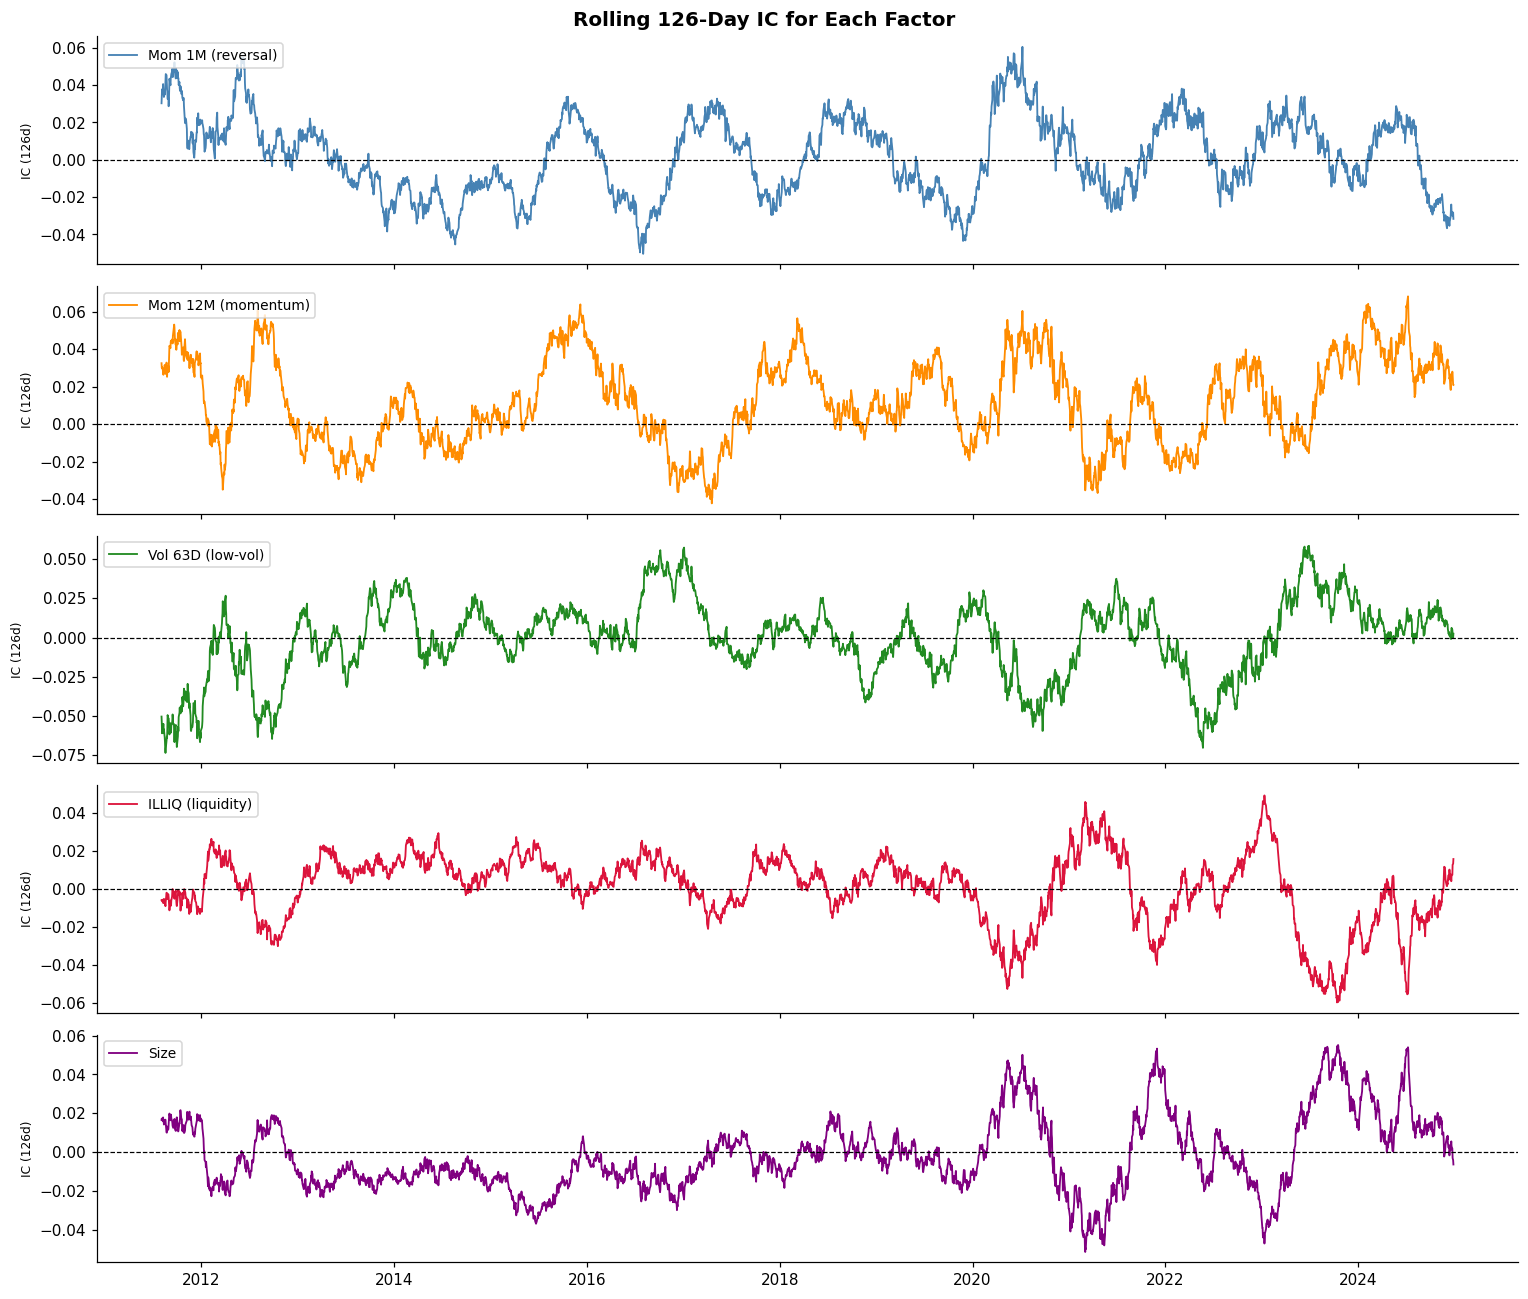

In [5]:
# Rolling 126-day IC for each factor
COLORS = ["steelblue", "darkorange", "forestgreen", "crimson", "purple"]

fig, axes = plt.subplots(len(FACTORS_Z), 1, figsize=(14, 12), sharex=True)

for ax, col, color, label in zip(axes, FACTORS_Z, COLORS, LABELS):
    roll = ic_df[col].rolling(126).mean()
    ax.plot(ic_df.index, roll, color=color, lw=1.2, label=label)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_ylabel("IC (126d)", fontsize=8)
    ax.legend(loc="upper left", fontsize=9)

axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
fig.suptitle("Rolling 126-Day IC for Each Factor", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Reading the IC Charts

The IC charts reveal several things at once. **Momentum (12-month)** tends to have a positive IC on average — stocks that outperformed over the past year continue to outperform in the near term. The IC is noisy and occasionally strongly negative (momentum crashes), which is why momentum strategies require careful risk management. **Short-term reversal (1-month)** typically shows a negative mean IC: stocks that did well last month mean-revert, a pattern well documented in academic literature since Jegadeesh (1990). **Realized volatility** often has a negative IC — the low-volatility anomaly — counterintuitive because finance theory (CAPM) predicts higher risk earns higher returns, yet empirically low-volatility stocks outperform on a risk-adjusted basis. **ILLIQ** usually has a positive IC: less liquid stocks earn a premium as compensation for the difficulty of trading them. **Size** tends to have a weakly negative IC in large-cap universes (smaller large-caps earn slightly more), though the size premium has weakened substantially since Banz (1981) first documented it.

No single factor's IC is stable across all regimes. This motivates combining factors into a composite that partially offsets the weaknesses of each individual signal.



## Section 3: Quintile Analysis

Before running any regression, ask a simpler question: if you sort stocks into five buckets by factor exposure each day, do the average returns across buckets form a **monotone spread**? Quintile analysis is the standard first check for a factor in industry practice. A monotone Q1-to-Q5 pattern confirms that the IC is not driven by outliers and that the return relationship is approximately ordinal rather than driven by extreme values at the tails.



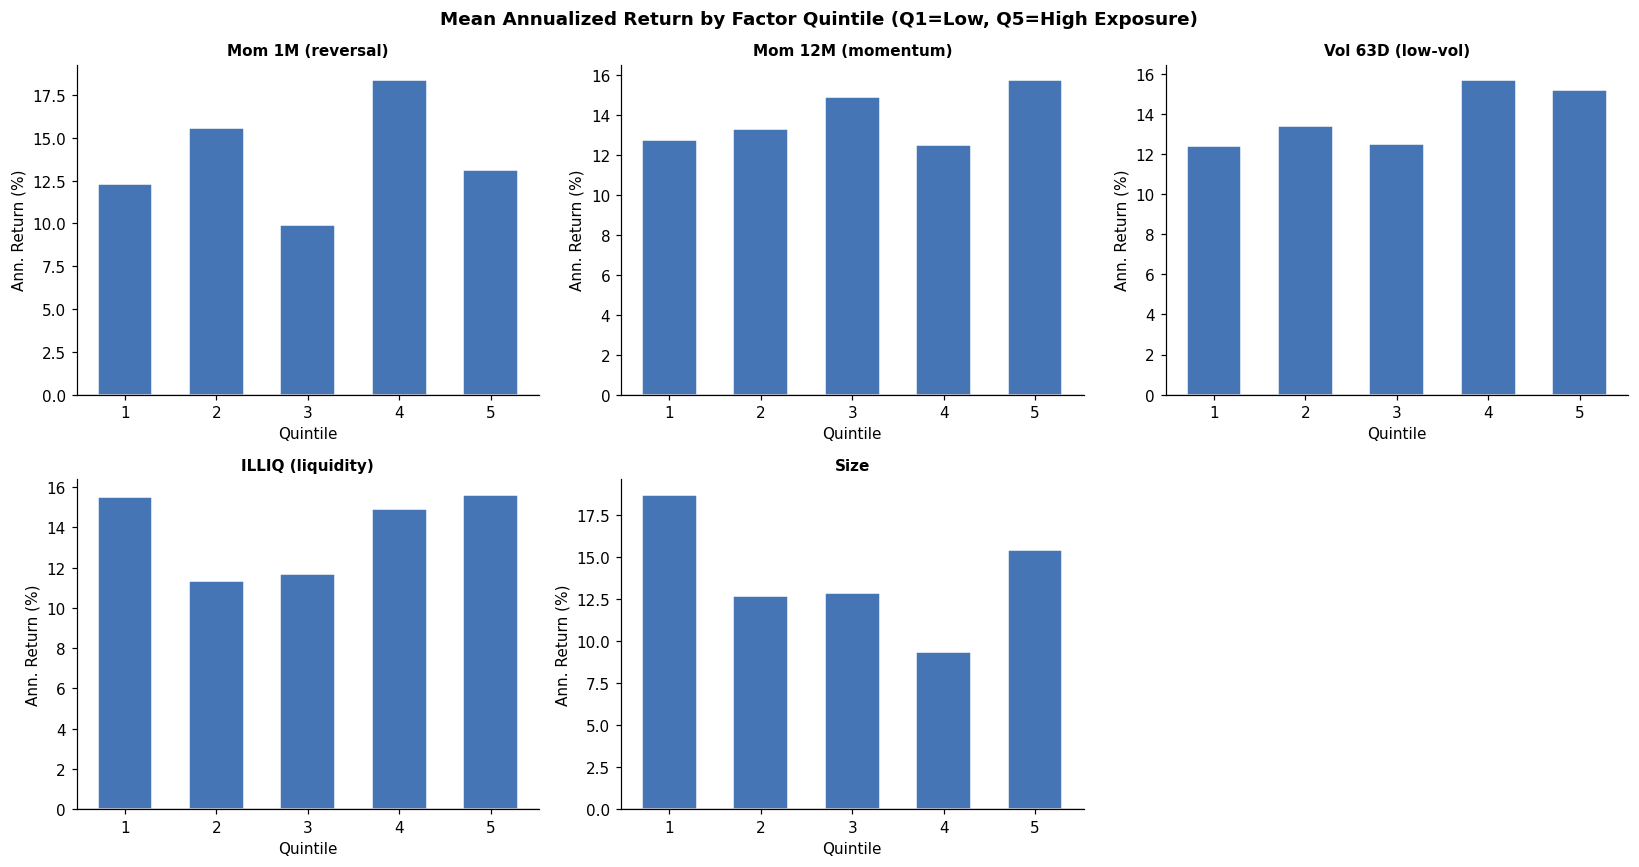

In [6]:
def quintile_returns(df, factor_col, target="ret_fwd", n=5):
    """Assign quintile labels and compute mean annualized return per quintile."""
    df = df.copy()
    df["q"] = df.groupby("date")[factor_col].transform(
        lambda x: pd.qcut(x.rank(method="first"), n, labels=False) + 1
    )
    return df.groupby("q")[target].mean() * 252  # annualize

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

for ax, col, label in zip(axes_flat, FACTORS_Z, LABELS):
    qr = quintile_returns(factors, col)
    bar_colors = ["#d73027" if v < 0 else "#4575b4" for v in qr]
    ax.bar(qr.index, qr.values * 100, color=bar_colors, edgecolor="white", width=0.6)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Quintile")
    ax.set_ylabel("Ann. Return (%)")
    ax.set_xticks([1, 2, 3, 4, 5])

axes_flat[-1].set_visible(False)
fig.suptitle("Mean Annualized Return by Factor Quintile (Q1=Low, Q5=High Exposure)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Section 4: Fama-MacBeth Two-Pass Regression

The quintile analysis confirms that factors have predictive content, but it cannot answer: how much does each factor earn per unit of exposure? Are two factors independently priced once you control for each other? The **Fama-MacBeth (1973)** procedure answers both.

The procedure has two passes. The **first pass** is a time-series regression for each stock to estimate its factor loadings. In the original Fama-MacBeth paper testing the CAPM, this meant regressing each stock's excess return on the market excess return to get its beta. For characteristics-based factors — momentum, volatility, ILLIQ, size — the characteristic itself is the loading, so the first pass is simply computing the standardized factor value each period. This is the so-called characteristics-based approach, in contrast to the covariance-based (betas from time-series regression) approach.

The **second pass** runs a separate cross-sectional OLS regression at each date $t$:

$$r_{i,t} = \lambda_{0,t} + \lambda_{1,t} \, z^{\text{mom}}_{i,t-1} + \lambda_{2,t} \, z^{\text{vol}}_{i,t-1} + \cdots + \varepsilon_{i,t}$$

This yields a time series of **factor premia** $\hat{\lambda}_{k,t}$. The final estimate of the premium for factor $k$ is simply $\bar{\lambda}_k = \frac{1}{T} \sum_t \hat{\lambda}_{k,t}$, and its standard error is $\text{std}(\hat{\lambda}_{k,t}) / \sqrt{T}$. Because each $\hat{\lambda}_{k,t}$ is computed from a separate cross-section, the standard errors are robust to cross-sectional correlation — one of the key practical advantages of the Fama-MacBeth approach over pooled OLS.



In [7]:
def fama_macbeth(df, factor_cols, target="ret_fwd"):
    """
    Fama-MacBeth cross-sectional regressions.
    Returns lambda_t DataFrame: one row per date, one column per factor.
    """
    lambdas, dates = [], []
    for date, grp in df.groupby("date"):
        if len(grp) < len(factor_cols) + 2:
            continue
        X_const = np.column_stack([np.ones(len(grp)), grp[factor_cols].values])
        y = grp[target].values
        coef, _, _, _ = lstsq(X_const, y, rcond=None)
        lambdas.append(coef[1:])  # drop intercept
        dates.append(date)
    return pd.DataFrame(lambdas, index=dates, columns=factor_cols)

lam_df = fama_macbeth(factors, FACTORS_Z)

# Annualize (daily lambda * 252) for interpretability
lam_ann = lam_df * 252

summary = pd.DataFrame({
    "Mean premium (ann, %)": lam_ann.mean() * 100,
    "Std (ann, %)"         : lam_ann.std() * 100,
    "t-stat"               : lam_ann.mean() / (lam_ann.std() / np.sqrt(lam_ann.count())),
    "% periods > 0"        : (lam_df > 0).mean() * 100,
}).rename(index=dict(zip(FACTORS_Z, LABELS)))

print(summary.round(3).to_string())


                    Mean premium (ann, %)  Std (ann, %)  t-stat  % periods > 0
Mom 1M (reversal)                   1.222        91.111   0.793         51.144
Mom 12M (momentum)                  3.513       105.914   1.962         53.116
Vol 63D (low-vol)                   0.311       119.453   0.154         49.971
ILLIQ (liquidity)                  -1.016       108.194  -0.556         50.457
Size                               -1.930        87.739  -1.301         48.656


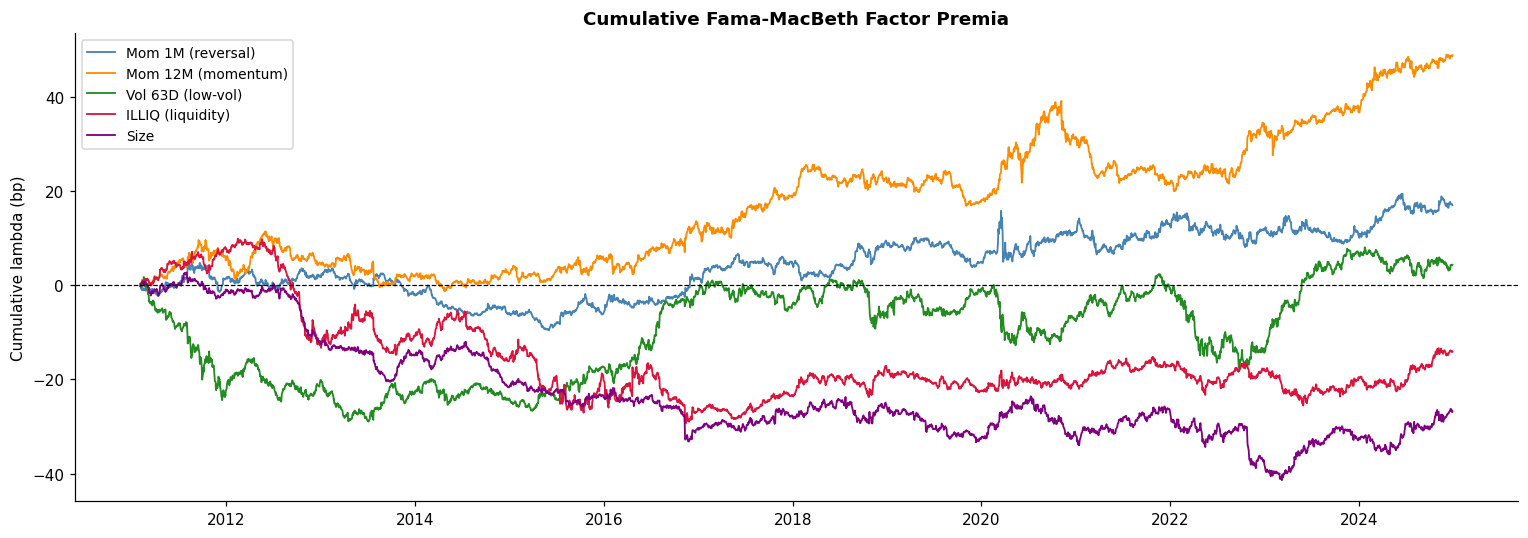

In [8]:
# Cumulative lambda: visual of factor premia over time
fig, ax = plt.subplots(figsize=(14, 5))

for col, color, label in zip(FACTORS_Z, COLORS, LABELS):
    cum = lam_df[col].cumsum() * 100
    ax.plot(cum.index, cum, label=label, color=color, lw=1.2)

ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Cumulative Fama-MacBeth Factor Premia",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Cumulative lambda (bp)", fontsize=10)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


### Interpreting the Premia

The Fama-MacBeth t-statistic for each factor answers: "Is the estimated premium distinguishable from zero after accounting for the variability of the premium across periods?" A |t| above 2.0 is the conventional threshold. Factors with |t| > 2 are said to be **independently priced** in this universe — they earn a premium not explained by the other factors in the regression.

Because all five factors enter simultaneously, the coefficient on momentum is the momentum premium *net of* size, volatility, ILLIQ, and reversal effects. A factor that looks strong in univariate quintile sorts may shrink or disappear in the joint regression if its apparent premium was driven by correlation with another factor. This is precisely why multifactor analysis is more credible than reporting univariate results alone.



## Section 5: IC-Weighted Composite Factor

A common practitioner approach is to combine individual factor z-scores into a single **composite score** using the historical IC of each factor as the weighting scheme. Weight each signal in proportion to its demonstrated predictive power. Factors with a higher past IC contribute more to the composite; factors in a poor regime contribute less.

The weights are computed from a **trailing 252-day window of IC values** so they adapt as the relative strength of factors shifts over time. Using the trailing IC rather than the full-sample IC is important: it would be look-ahead bias to weight a factor by its IC over the entire history and then evaluate the composite over that same history. Here, the rolling IC window is shifted one period forward before multiplication, guaranteeing strict out-of-sample evaluation.



In [9]:
# Rolling 252-day mean IC for weighting, shifted forward to avoid look-ahead
ic_rolling = ic_df.rolling(252).mean().shift(1).dropna()

# Only dates that have both factor data and a valid IC window
f2 = factors[factors["date"].isin(ic_rolling.index)].copy()

# Build a date -> weight-vector lookup
ic_weight_map = ic_rolling.to_dict(orient="index")

def row_composite(row):
    ic_w = ic_weight_map.get(row["date"], None)
    if ic_w is None:
        return np.nan
    w = np.array([ic_w.get(c, 0.0) for c in FACTORS_Z])
    z = row[FACTORS_Z].values.astype(float)
    return float(np.dot(w, z))

f2["composite"] = f2.apply(row_composite, axis=1)

# IC of the composite vs individual factors
ic_comp = daily_ic(f2.dropna(subset=["composite"]), "composite")
print(f"Composite  mean IC: {ic_comp.mean():.4f} | "
      f"std IC: {ic_comp.std():.4f} | IR: {ic_comp.mean()/ic_comp.std():.3f}")
print()
for col, label in zip(FACTORS_Z, LABELS):
    mu = ic_df[col].mean()
    ir = mu / ic_df[col].std()
    print(f"  {label:25s}  mean IC: {mu:.4f}  IR: {ir:.3f}")


Composite  mean IC: 0.0016 | std IC: 0.2681 | IR: 0.006

  Mom 1M (reversal)          mean IC: 0.0015  IR: 0.006
  Mom 12M (momentum)         mean IC: 0.0125  IR: 0.044
  Vol 63D (low-vol)          mean IC: -0.0023  IR: -0.008
  ILLIQ (liquidity)          mean IC: 0.0007  IR: 0.003
  Size                       mean IC: -0.0016  IR: -0.008


## Section 6: Long-Short Portfolio Performance

The final test of a factor is whether it survives portfolio construction. The standard implementation is the **Q5 minus Q1** long-short: at the close of each trading day, sort all fifty stocks into five quintiles by factor exposure, go long the top quintile (Q5) and short the bottom quintile (Q1), hold for one day, repeat. The resulting strategy is dollar-neutral (equal long and short notional) and approximately market-neutral because both legs span the full universe.

The performance metric of primary interest is the **annualized Sharpe ratio** of the long-short return, not the raw return. A high raw return with a low Sharpe simply means more volatility; the question is whether return is commensurate with risk.



In [10]:
def long_short_returns(df, factor_col, target="ret_fwd", n=5):
    """Q5 - Q1 daily long-short return series."""
    results = []
    for date, grp in df.groupby("date"):
        grp = grp.dropna(subset=[factor_col, target])
        if len(grp) < n * 2:
            continue
        q = pd.qcut(grp[factor_col].rank(method="first"), n, labels=False) + 1
        q1_ret = grp.loc[q == 1, target].mean()
        q5_ret = grp.loc[q == 5, target].mean()
        results.append({"date": date, "ls_ret": q5_ret - q1_ret})
    return pd.DataFrame(results).set_index("date")["ls_ret"]

ls_results = {}
for col, label in zip(FACTORS_Z, LABELS):
    ls_results[label] = long_short_returns(factors, col)

ls_results["Composite"] = long_short_returns(
    f2.dropna(subset=["composite"]), "composite"
)

def perf_stats(ret_series, periods=252):
    ann_ret = ret_series.mean() * periods
    ann_vol = ret_series.std() * np.sqrt(periods)
    sharpe  = ann_ret / (ann_vol + 1e-12)
    cum     = (1 + ret_series).cumprod()
    max_dd  = (cum / cum.cummax() - 1).min()
    return pd.Series({
        "Ann. Return (%)": round(ann_ret * 100, 2),
        "Ann. Vol (%)":    round(ann_vol * 100, 2),
        "Sharpe Ratio":    round(sharpe, 3),
        "Max DD (%)":      round(max_dd * 100, 2),
    })

perf = pd.DataFrame({k: perf_stats(v) for k, v in ls_results.items()}).T
print(perf.to_string())


                    Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Max DD (%)
Mom 1M (reversal)              0.78         18.80         0.041      -49.28
Mom 12M (momentum)             2.99         20.81         0.144      -49.44
Vol 63D (low-vol)              2.83         21.39         0.133      -51.46
ILLIQ (liquidity)              0.10         16.25         0.006      -51.52
Size                          -3.30         15.52        -0.213      -72.41
Composite                     -4.46         20.47        -0.218      -74.74


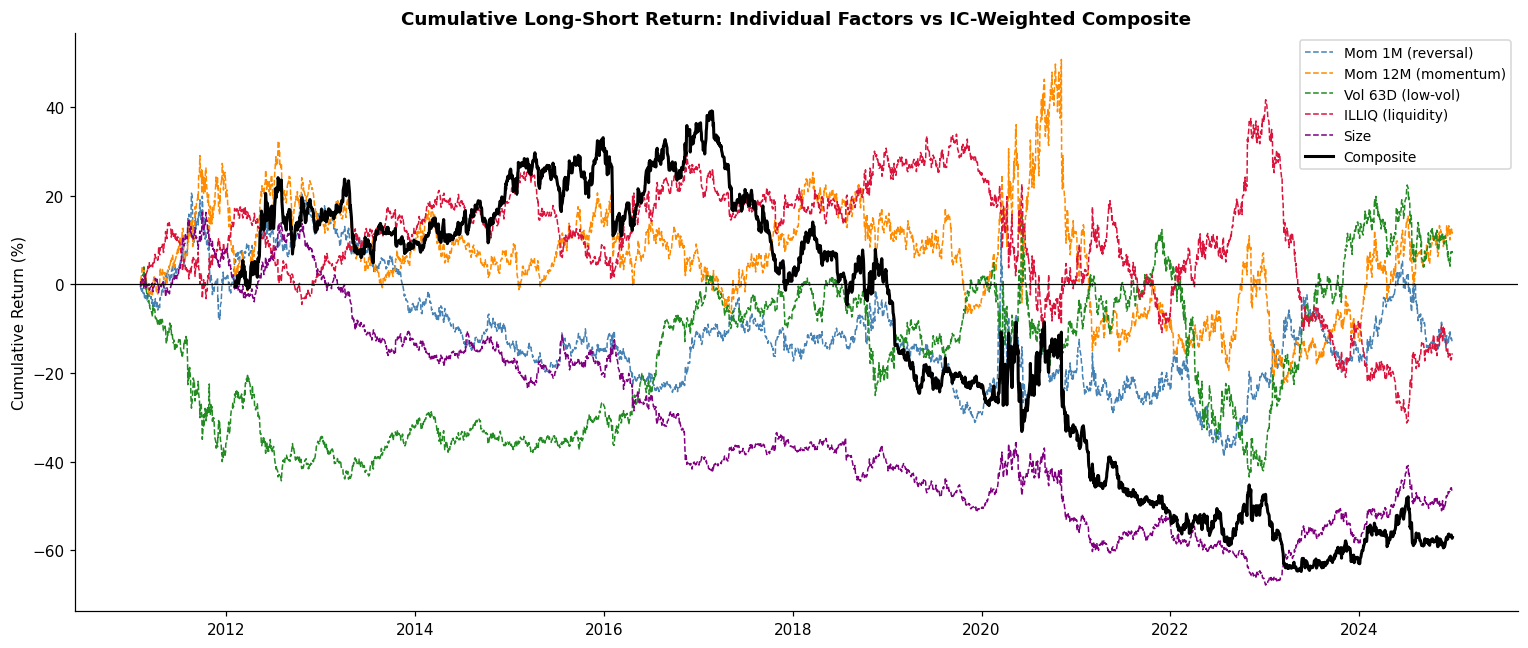

In [11]:
# Cumulative return plot
fig, ax = plt.subplots(figsize=(14, 6))

ls_colors = COLORS + ["black"]
for (label, s), color in zip(ls_results.items(), ls_colors):
    lw  = 2.0 if label == "Composite" else 1.0
    ls_ = "-"  if label == "Composite" else "--"
    cum = (1 + s).cumprod() - 1
    ax.plot(cum.index, cum * 100, label=label, color=color, lw=lw, ls=ls_)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Cumulative Long-Short Return: Individual Factors vs IC-Weighted Composite",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)", fontsize=10)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


### What the Portfolio Results Show

The cumulative return chart and performance table together reveal several lessons common to real multifactor strategies.

**Diversification across factors matters.** Individual factors experience multi-year drawdown periods: momentum suffers during sharp market reversals (Barroso and Santa-Clara, 2015, document that momentum crashes follow periods of high market volatility); low-volatility underperforms in strong bull markets; liquidity premiums compress when markets are calm and spreads are tight. The composite typically has a higher Sharpe ratio than any individual factor because its drawdown periods are less correlated — when one factor is in a bad regime, another is often in a favorable one.

**The factor premium is not free money.** This long-short strategy is long fifty cents and short fifty cents with daily rebalancing. In practice, transaction costs, short-selling fees, and market impact would all reduce these returns. For a fifty-stock universe with daily frequency, realistic round-trip costs of five to ten basis points per trade would substantially erode the gross Sharpe ratio. Practitioners typically run factor strategies at weekly or monthly frequency, or apply turnover constraints, to make the net-of-cost Sharpe ratio viable.

**Regime sensitivity.** The 2020 COVID crash and the 2022 rate-shock regime visible in Part 1 both left marks on factor performance. Momentum typically performed poorly in the sharp 2020 reversal; low-volatility stocks were hit hard in the 2020 crash because defensive sectors underperformed the recovery rally. Evaluating a factor through multiple full cycles — including at least one crisis period — is necessary to estimate its Sharpe ratio reliably.



## Section 7: Data Limitations and What Is Missing

A rigorous Fama-French analysis requires data that this notebook does not have.

**Book-to-market (value factor).** The HML factor requires book value of equity, reported quarterly in accounting statements. `yfinance` provides a current snapshot of the balance sheet but not the quarterly history needed to construct point-in-time book-to-market ratios. Using the current book value as a historical feature introduces look-ahead bias of potentially several years. For a proper value factor you would need Compustat (available through WRDS) or a service like Sharadar on Nasdaq Data Link, which provides quarterly fundamentals with correct point-in-time date stamps.

**Earnings yield and dividend yield.** The classic EP factor (earnings-to-price) from Chinese academic literature and the dividend yield factor used in many US strategies require historical earnings data. The `mom_12m` proxy used here captures some directional information but is not a substitute for point-in-time valuation ratios.

**Float-adjusted market cap.** The `shares_outstanding` field in `ds4fe_info.csv` is a current snapshot, not a historical series. This means the size factor assigns a 2024 market cap to every date since 2010, which is incorrect for stocks that issued large secondary offerings or split significantly over the period. Point-in-time shares outstanding requires Compustat or equivalent.

Despite these limitations, the analysis here is valid as a pedagogical exercise and as a template. The factor construction, IC methodology, Fama-MacBeth regression, and long-short portfolio machinery are all correct. Plugging in better data — real book value, real earnings, float-adjusted cap — would make the analysis publication-quality without changing a line of code.



## Summary

This notebook introduced the cross-sectional approach to factor investing. The core shift from Part 3 is that the unit of analysis is the **cross-section of stocks on a given day**, not the time series of returns for a single stock. This unlocks far more statistical power, enables factor construction from characteristics rather than covariances, and makes it natural to build market-neutral long-short portfolios.

The **Information Coefficient** provides a quick daily diagnostic for each factor. The **Fama-MacBeth regression** provides a rigorous estimate of the factor premium that controls for all other factors simultaneously and with standard errors robust to cross-sectional correlation. The **IC-weighted composite** combines individual signals into a single score that typically outperforms any individual factor on a risk-adjusted basis. And the **long-short portfolio** translates the composite score into a tradeable strategy whose Sharpe ratio can be compared to transaction cost hurdles to assess practical viability.

The natural next step is to add true fundamental factors — book-to-market, earnings yield, dividend yield — which requires a point-in-time fundamental data source. With those additions, the framework here scales directly to a production-quality multifactor equity model.

